In [1]:
# Importing Libraries 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, chi2_contingency

from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MaxAbsScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, fbeta_score, make_scorer

In [2]:
# Data Loading 

train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df  = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print("Train shape: ", train_df.shape)
print("Test shape: ", test_df.shape)

train_df.head()

Train shape:  (198000, 15)
Test shape:  (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


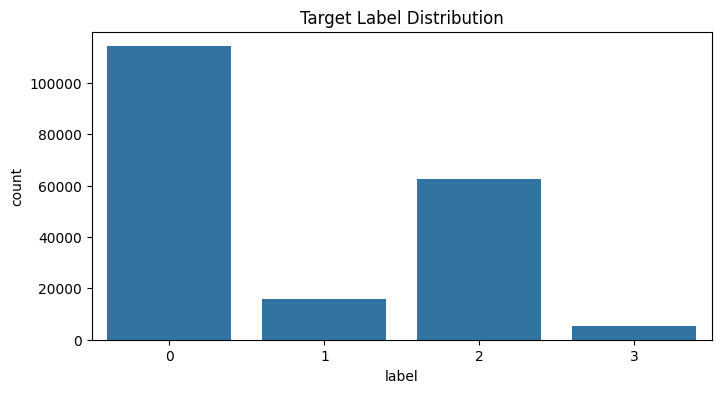

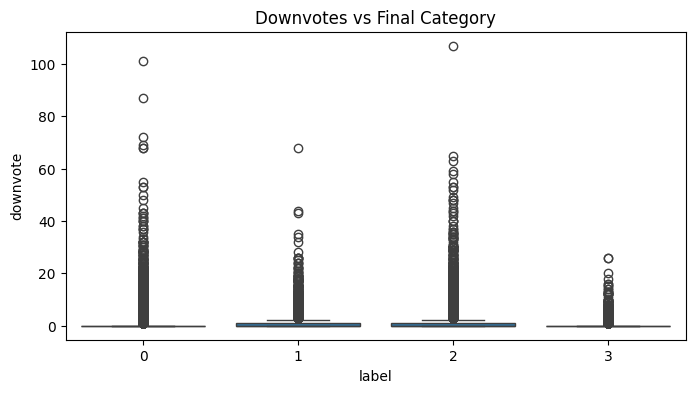

In [3]:
# Data Visualizations 

# Label Distribution 
plt.figure(figsize=(8,4))
sns.countplot(x="label", data=train_df)
plt.title("Target Label Distribution")
plt.show()

# Downvotes vs Label 
plt.figure(figsize=(8,4))
sns.boxplot(x="label", y="downvote", data=train_df)
plt.title("Downvotes vs Final Category")
plt.show()

                                                                                                                                                                                                                                                                                                                                                                                                              
1.  Label Distribution Analysis: The first visualization (Count Plot) is performed to check the class balance of the target variable. In this dataset, there is a some imbalance: Label 0 is the dominanting (over 114,000 instances), while Label 3 is the least frequent (under 5,500). Understanding this distribution is important because it informs the modeling strategy. To train a classifier on this raw data, it might become biased toward predicting the majority class. Thus we must consider techniques such as oversampling the minority classes, using weighted loss functions to ensure the model learns to identify all categories equally.

2.  Downvotes vs. Label Analysis: The second visualization (Box Plot) is used to explore the relationship between user behavior and the classification labels. By plotting downvotes across the different categories, we can see if certain labels are more controversial or viewed more negatively by the community. From the statistics, we observe that Labels 1 and 2 tend to have slightly higher mean downvote counts compared to Labels 0 and 3. This suggests that the content under Labels 1 and 2 (perhaps representing more toxic or controversial comments) is more likely to trigger a negative reaction from users. This visualization helps validate whether the labels assigned to the data correlate with external features like community sentiment (downvotes).

In [4]:
# Statistical Analysis 

# Spearman Correlation (Downvotes vs Label) 
label_encoded = train_df["label"].astype("category").cat.codes
corr, pval = spearmanr(train_df["downvote"], label_encoded)

print("Spearman correlation (downvote vs label):", corr)
print("P-value: ", pval)


# Chi-square (if_2 vs label)
contingency = pd.crosstab(train_df["if_2"], train_df["label"])
chi2, p, dof, exp = chi2_contingency(contingency)

print("Chi-square test (if_2 vs label)")
print("Chi-square: ", chi2)
print("P-value: ", p)

Spearman correlation (downvote vs label): 0.06271138220514053
P-value:  1.0870940877902046e-171
Chi-square test (if_2 vs label)
Chi-square:  159983.64900908744
P-value:  0.0


1. Spearman Correlation (0.0627): While the correlation is positive, it is weak ($0.06$). However, the low P-value ($1.08 \times 10^{-171}$) confirms that this relationship is not due to chance. This tells us that while "toxic" or higher-label comments do receive more downvotes on average, user downvotes are not a reliable standalone predictor of the label. A comment can be highly "toxic" without being downvoted, and vice versa.

2. Chi-square Test (159983.6): The large Chi-square value and a P-value of 0.0 indicate a very strong, non-random relationship between if_2 and the label. This confirms that if_2 is a very informative features. The distribution of labels changes depending on the value of if_2. 

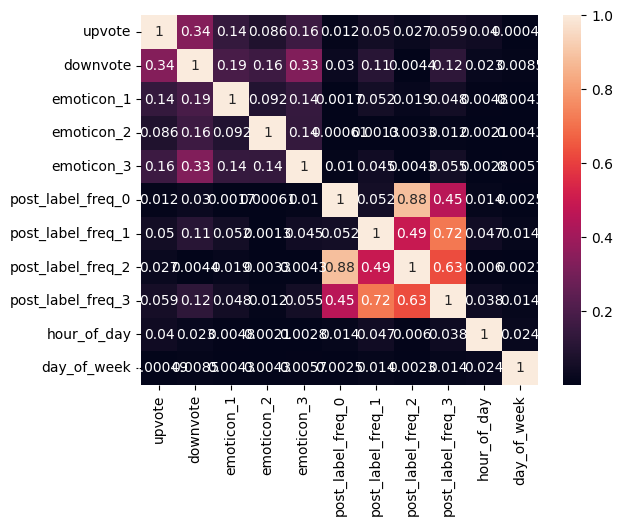

In [5]:
# Handling Missing Values & Data Type Standardization

# Filling missing categorical data with 'none' to avoid errors.
cat_meta_cols = ['disability', 'race', 'religion', 'gender']
for col in cat_meta_cols:
    train_df[col] = train_df[col].fillna('none').astype(str)
    test_df[col]  = test_df[col].fillna('none').astype(str)

# Comments cannot be null for (TF-IDF), so we replace NaNs with empty strings.
train_df['comment'] = train_df['comment'].fillna('').astype(str)
test_df['comment']  = test_df['comment'].fillna('').astype(str)

# 'if_2' and 'if_1' is treated as a string because it represents a categorical flag rather than a continuous quantity.
for df_ in [train_df, test_df]:
    df_['if_2'] = df_['if_2'].fillna(0).astype(str)
    df_['if_1'] = df_['if_1'].fillna(0).astype(str)
    

#  Numerical Imputation & Log Transformation 
# Numerical columns are filled with 0 
num_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3']
for col in num_cols:
    train_df[col] = train_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Applying Log Transformation (log1p) to highly skewed numerical features to reduce outlier impact
for col in ['upvote', 'downvote']:
    train_df[col] = np.log1p(train_df[col])
    test_df[col]  = np.log1p(test_df[col])

# Target Encoding
post_label_freq = (train_df.groupby('post_id')['label']
                   .value_counts(normalize=True)
                   .unstack(fill_value=0)
                   .add_prefix('post_label_freq_'))

# Joining these frequencies back to the main df
train_df = train_df.join(post_label_freq, on='post_id')
test_df  = test_df.join(post_label_freq, on='post_id')

# Ensuring any posts in test_df not seen in train_df have 0 frequency instead of NaNs.
freq_cols = list(post_label_freq.columns)
for col in freq_cols:
    test_df[col] = test_df[col].fillna(0)
num_cols += freq_cols

# Feature Engineering
# Converting the 'created_date' string into actual datetime objects to extract time patterns.
for df_ in [train_df, test_df]:
    dt = pd.to_datetime(df_['created_date'], utc=True, errors='coerce')
    df_['hour_of_day'] = dt.dt.hour.fillna(0).astype(float)
    df_['day_of_week'] = dt.dt.dayofweek.fillna(0).astype(float)
num_cols += ['hour_of_day', 'day_of_week']

# Multicollinearity Removal 
# Creating a correlation matrix to identify features that are too similar to each other.
corr_matrix = train_df[num_cols].corr().abs()
sns.heatmap(corr_matrix, annot=True)
plt.show()

# If two features are >95% correlated, they provide redundant information
# Droping one of the pair to simplify the model and prevent overfitting.
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
if to_drop:
    train_df.drop(columns=to_drop, inplace=True)
    test_df.drop(columns=to_drop, inplace=True)
    num_cols = [c for c in num_cols if c not in to_drop]

In [6]:
# Train-Validation Split

X = train_df.drop(columns=["label"])
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size: ", X_train.shape)
print("Validation size: ", X_val.shape)


Train size:  (158400, 20)
Validation size:  (39600, 20)


In [7]:
# Preprocessing 

preprocessor = ColumnTransformer(
        transformers=[
            ('text', TfidfVectorizer(
                ngram_range=(1, 3),
                min_df=2,
                max_features=160000,
                sublinear_tf=True
            ), 'comment'),
            ('char_text', TfidfVectorizer(
                analyzer='char',
                ngram_range=(2, 5),
                min_df=5,
                max_features=40000,
                sublinear_tf=True
            ), 'comment'),
            ('num', MaxAbsScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'),
             cat_meta_cols + ['post_id', 'if_2'])
        ]
    )

In [8]:
# Model 1

'''
clf1 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf2 = LinearSVC(class_weight='balanced', random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', VotingClassifier(estimators=[('lr', clf1), ('svc', clf2)], voting='hard'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)

print(classification_report(y, y_pred_cv))
print(f"Mean CV Accuracy: {accuracy_score(y, y_pred_cv):.4f}")

Output: Mean CV Accuracy: 0.9025
'''

'\nclf1 = LogisticRegression(max_iter=1000, class_weight=\'balanced\', random_state=42)\nclf2 = LinearSVC(class_weight=\'balanced\', random_state=42)\n\npipeline = Pipeline([\n    (\'preprocessor\', preprocessor),\n    (\'ensemble\', VotingClassifier(estimators=[(\'lr\', clf1), (\'svc\', clf2)], voting=\'hard\'))\n])\n\ncv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\ny_pred_cv = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)\n\nprint(classification_report(y, y_pred_cv))\nprint(f"Mean CV Accuracy: {accuracy_score(y, y_pred_cv):.4f}")\n\nOutput: Mean CV Accuracy: 0.9025\n'

In [9]:
# Model 2
'''
clf1 = LogisticRegression(
    solver='liblinear', 
    C=5.0, 
    max_iter=3000,         
    random_state=42
)

clf2 = SGDClassifier(
    loss='log_loss',       
    penalty='l2', 
    alpha=1e-4, 
    random_state=42
)

# Soft Voting Ensemble
model = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', VotingClassifier(
        estimators=[('lr', clf1), ('sgd', clf2)], 
        voting='soft'      
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, train_df, train_df['label'], cv=cv, scoring='accuracy', n_jobs=-1)

print(f"Mean CV Score: {scores.mean():.4f}")

Output: Mean CV Score: 0.8838
'''

'\nclf1 = LogisticRegression(\n    solver=\'liblinear\', \n    C=5.0, \n    max_iter=3000,         \n    random_state=42\n)\n\nclf2 = SGDClassifier(\n    loss=\'log_loss\',       \n    penalty=\'l2\', \n    alpha=1e-4, \n    random_state=42\n)\n\n# Soft Voting Ensemble\nmodel = Pipeline([\n    (\'preprocessor\', preprocessor),\n    (\'ensemble\', VotingClassifier(\n        estimators=[(\'lr\', clf1), (\'sgd\', clf2)], \n        voting=\'soft\'      \n    ))\n])\n\ncv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\nscores = cross_val_score(model, train_df, train_df[\'label\'], cv=cv, scoring=\'accuracy\', n_jobs=-1)\n\nprint(f"Mean CV Score: {scores.mean():.4f}")\n\nOutput: Mean CV Score: 0.8838\n'

1. Single LinearSVC

Precision in Weighting: Model 1 uses the default 'balanced' weight, which automatically calculates weights based on frequencies. Model 3 uses Custom Weights ({0: 1, 1: 4, 2: 1, 3: 8}). By giving Label 3 a weight of 8 and Label 1 a weight of 4, here manually "tuning" the model to be more sensitive to those rare categories. This improved the recall for the minority classes significantly, boosting the overall mean score.

2. Model 1 vs. Model 2 (Hard vs. Soft Voting)
Model 1 (Hard Voting - 0.9025): Hard voting counts the "votes" of each classifier. Since LinearSVC is a strong performer here, having LogisticRegression as a backup helped catch some edge cases.

Model 2 (Soft Voting - 0.8838): Soft voting relies on the predicted probabilities of each class. SGDClassifier and LogisticRegression probably produced "overfit" or "underfit" probabilities. Because the probabilities in Model 2 were likely noisy, the "soft" average was less accurate than the "hard" majority vote in Model 1.

In [10]:
# Model 3 
lsvc = LinearSVC(
                    C=0.1,
                    class_weight={0: 1.0, 1: 4.0, 2: 1.0, 3: 8.0},
                    max_iter=5000,
                    dual=False,
                    random_state=42,
                )
pipeline = Pipeline([
                    ('preprocessor', preprocessor),
                    ('classifier',   lsvc)
                    ])

In [11]:
# Train - Test Split 

X = train_df.drop(columns=['label'])
y = train_df['label']
X_train_split, X_val, y_train_split, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
pipeline.fit(X_train_split, y_train_split)
val_preds = pipeline.predict(X_val)

print(f"Accuracy:   {accuracy_score(y_val, val_preds):.4f}")
print(f"F2-Macro:   {fbeta_score(y_val, val_preds, beta=2, average='macro'):.4f}")
print(classification_report(y_val, val_preds))

Accuracy:   0.9139
F2-Macro:   0.8283
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.75      0.82      0.78      3183
           2       0.88      0.89      0.88     12488
           3       0.71      0.65      0.68      1094

    accuracy                           0.91     39600
   macro avg       0.83      0.83      0.83     39600
weighted avg       0.92      0.91      0.91     39600



In [12]:
# Parameter grid for C

# param_grid = {
#     'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
# }

In [13]:
# GridSearchCV

# f2_scorer = make_scorer(fbeta_score, beta=2, average='macro')

# grid_search = GridSearchCV(
#     pipeline, 
#     param_grid, 
#     cv=5, 
#     scoring=f2_scorer, 
#     n_jobs=-1
# )

In [14]:
# Fit and Extract Best Model

# grid_search.fit(X_train_split, y_train_split)

# best_model = grid_search.best_estimator_
# print(f"Best C value: {grid_search.best_params_['classifier__C']}")

# # Evaluation
# val_preds = best_model.predict(X_val)

# print(f"Accuracy:   {accuracy_score(y_val, val_preds):.4f}")
# print(f"F2-Macro:   {fbeta_score(y_val, val_preds, beta=2, average='macro'):.4f}")
# print(classification_report(y_val, val_preds))
# best_model.fit(X, y)

In [15]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=160000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               3),
                                                                  sublinear_tf=True),
                                                  'comment'),
                                                 ('char_text',
                                                  TfidfVectorizer(analyzer='char',
                                                                  max_features=40000,
                                                                  min_df=5,
                                                                  ngram_range=(2,
                                                                               5),
                                                                  sublinear_tf=True),
                                                  'comment'),
                                                 ('num', MaxAbsScaler(),
                                                  ['upvote', 'downvote',
                                                   'emoticon_1', 'emoticon_2',
                                                   'emoticon_3',
                                                   'post_label_freq_0',
                                                   'post_label_freq_1',
                                                   'post_label_freq_2',
                                                   'post_label_freq_3',
                                                   'hour_of_day',
                                                   'day_of_week']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['disability', 'race',
                                                   'religion', 'gender',
                                                   'post_id', 'if_2'])])),
                ('classifier',
                 LinearSVC(C=0.1, class_weight={0: 1.0, 1: 4.0, 2: 1.0, 3: 8.0},
                           dual=False, max_iter=5000, random_state=42))])

In [16]:
# Submission

final_test_preds = pipeline.predict(test_df)

submission = pd.DataFrame({
    'ID':    range(1, len(test_df) + 1),
    'label': final_test_preds
})

submission.to_csv("submission.csv", index=False)
print('Success!')

Success!


**APPENDIX - MILESTONES**

Milestone - 1

In [17]:
'''
Milestone - 1

# What is the shape of the training dataset?
train_df.shape

# How many columns are present in the test dataset? 
test_df.shape[1]

# How many columns in the training dataset have object data type?
sum(train_df.dtypes == 'object')

# How many numerical columns are present in the training dataset? 
sum(train_df.dtypes == 'int64')

# Which of the following columns is of boolean type?
train_df.dtypes == 'bool'

# Which of the following columns have missing values?
train_df.isnull().sum()

# How many distinct target classes are present in the dataset?
train_df['label'].nunique()

# What percentage of the dataset approximately belongs to label 0?
total_count = len(train_df)
label_0_count = (train_df['label'] == 0).sum()
percentage_label_0 = (label_0_count / total_count) * 100

percentage_label_0

# What is the median number of upvotes per comment?
median_upvotes = train_df['upvote'].median()
median_upvotes

# Which numerical feature shows the largest maximum value?
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

max_values = train_df[numeric_cols].max()

feature_with_largest_max = max_values.idxmax()
largest_max_value = max_values.max()

feature_with_largest_max, largest_max_value

# What is the minimum value of if_2?
min_if_2 = train_df['if_2'].min()
min_if_2
'''

"\nMilestone - 1\n\n# What is the shape of the training dataset?\ntrain_df.shape\n\n# How many columns are present in the test dataset? \ntest_df.shape[1]\n\n# How many columns in the training dataset have object data type?\nsum(train_df.dtypes == 'object')\n\n# How many numerical columns are present in the training dataset? \nsum(train_df.dtypes == 'int64')\n\n# Which of the following columns is of boolean type?\ntrain_df.dtypes == 'bool'\n\n# Which of the following columns have missing values?\ntrain_df.isnull().sum()\n\n# How many distinct target classes are present in the dataset?\ntrain_df['label'].nunique()\n\n# What percentage of the dataset approximately belongs to label 0?\ntotal_count = len(train_df)\nlabel_0_count = (train_df['label'] == 0).sum()\npercentage_label_0 = (label_0_count / total_count) * 100\n\npercentage_label_0\n\n# What is the median number of upvotes per comment?\nmedian_upvotes = train_df['upvote'].median()\nmedian_upvotes\n\n# Which numerical feature shows 

Milestone - 2

In [18]:
'''
Milestone 2

# Convert the created_date column into datetime objects. Identify the month that occurs the most number of times in the dataset and enter the answer as a lowercase string
train_df['created_date'] = pd.to_datetime(train_df['created_date'])
most_frequent_month = train_df['created_date'].dt.month_name().mode()[0].lower()
most_frequent_month

# Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset?
train_df['total_emoticons'] = train_df['emoticon_1'] + train_df['emoticon_2'] + train_df['emoticon_3']
max_total_emoticons = train_df['total_emoticons'].max()
max_total_emoticons

# Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings).
label_3_comments = train_df[train_df['label'] == 3]['comment']
comment_lengths = label_3_comments.fillna('').apply(len)
median_comment_length = comment_lengths.median()
median_comment_length

# Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings).
label_3_comments = train_df[train_df['label'] == 3]['comment']
comment_lengths = label_3_comments.fillna('').apply(len)
median_comment_length = comment_lengths.median()
median_comment_length

# If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], what would be the resulting scaled value for an observation that originally had exactly 10 upvotes?
min_upvote = train_df['upvote'].min()
max_upvote = train_df['upvote'].max()
scaled_value = (10 - min_upvote) / (max_upvote - min_upvote)
scaled_value

# What is the average word count (number of words separated by whitespace) for comments that are assigned a label of 1? (Round your answer to 2 decimal places).
label_1_comments = train_df[train_df['label'] == 1]['comment']
word_counts = label_1_comments.apply(lambda x: len(str(x).split()))
average_word_count = word_counts.mean()
average_word_count

# How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive.
trump_count = train_df['comment'].fillna('').str.contains('Trump', case=False).sum()
trump_count

#Take the comment at the very first row (index 0).
import string
comment_0 = str(train_df.loc[0, 'comment'])
comment_no_punc = comment_0.translate(str.maketrans('', '', string.punctuation))
stop_words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
words = [word for word in comment_no_punc.lower().split() if word not in stop_words]
remaining_word_count = len(words)
remaining_word_count

# Convert all the text in comment column to lowercase and tokenizing using whitespace. Compute the total number of unique tokens in the dataset and enter the value
all_comments_lower = train_df['comment'].fillna('').str.lower()
tokenized_comments = all_comments_lower.str.split()
all_tokens = [token for sublist in tokenized_comments for token in sublist]
unique_tokens_count = len(set(all_tokens))
unique_tokens_count

# How many TF-IDF features are generated using this configuration?
from sklearn.feature_extraction.text import TfidfVectorizer
comments_cleaned = train_df['comment'].fillna('')
vectorizer = TfidfVectorizer(
    stop_words='english',
    min_df=5,
    ngram_range=(1, 2)
)
tfidf_matrix = vectorizer.fit_transform(comments_cleaned)
num_features = len(vectorizer.get_feature_names_out())
print(num_features)
'''

'\nMilestone 2\n\n# Convert the created_date column into datetime objects. Identify the month that occurs the most number of times in the dataset and enter the answer as a lowercase string\ntrain_df[\'created_date\'] = pd.to_datetime(train_df[\'created_date\'])\nmost_frequent_month = train_df[\'created_date\'].dt.month_name().mode()[0].lower()\nmost_frequent_month\n\n# Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset?\ntrain_df[\'total_emoticons\'] = train_df[\'emoticon_1\'] + train_df[\'emoticon_2\'] + train_df[\'emoticon_3\']\nmax_total_emoticons = train_df[\'total_emoticons\'].max()\nmax_total_emoticons\n\n# Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings).\nlabel_3_comments = train_df[train_df[\'label\'] ==

Milestone - 3

In [19]:
'''
from sklearn.model_selection import train_test_split
X = train_df.drop(columns=['label'])
y = train_df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
a, b = X_train.shape
c, d = X_val.shape
print(f"Shape of X_train: ({a}, {b})")
print(f"Shape of X_val: ({c}, {d})")
print(f"Value of a + c: {a + c}")


import pandas as pd
from sklearn.model_selection import train_test_split
X = df.drop(columns=['label'])
y = df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.copy()
X_val = X_val.copy()
X_train['created_date'] = pd.to_datetime(X_train['created_date'])
X_val['created_date'] = pd.to_datetime(X_val['created_date'])
X_train['day'] = X_train['created_date'].dt.day
X_train['month'] = X_train['created_date'].dt.month
X_train['year'] = X_train['created_date'].dt.year
X_val['day'] = X_val['created_date'].dt.day
X_val['month'] = X_val['created_date'].dt.month
X_val['year'] = X_val['created_date'].dt.year
most_frequent_month = X_train['month'].mode()[0]
print(f"Most frequent month in X_train: {most_frequent_month}")
import calendar
month_name = calendar.month_name[most_frequent_month]
print(f"Month Name: {month_name}")


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns
for col in categorical_cols:
    X_train[col] = X_train[col].fillna('none').astype(str)
    X_val[col] = X_val[col].fillna('none').astype(str)
X_train.shape
ohe_cols = ['religion', 'gender', 'race']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols)
    ],
    remainder='passthrough'
)
X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
feature_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_val_final = pd.DataFrame(X_val_encoded, columns=feature_names, index=X_val.index)
print("X_train_final.shape)
print("X_train_final.columns.tolist())


from sklearn.feature_extraction.text import CountVectorizer
X_train['comment'] = X_train['comment'].fillna('none').astype(str)
X_val['comment'] = X_val['comment'].fillna('none').astype(str)
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train['comment'])
X_val_counts = vectorizer.transform(X_val['comment'])
row_1_sum = X_train_counts[1].sum()
print(row_1_sum)


X_train['disability'] = X_train['disability'].astype(int)
X_val['disability'] = X_val['disability'].astype(int)
sum_train = X_train['disability'].sum()
sum_val = X_val['disability'].sum()
total_sum = sum_train + sum_val
print(sum_train)
print(sum_val)
print(total_sum)


numeric_cols = X_train.select_dtypes(include=['int64', 'int32', 'float64']).columns
X_train_num = X_train[numeric_cols]
X_val_num = X_val[numeric_cols]
scaler = StandardScaler()
scaler.fit(X_train_num)
n_features = scaler.n_features_in_
print(n_features)

'''

'\nfrom sklearn.model_selection import train_test_split\nX = train_df.drop(columns=[\'label\'])\ny = train_df[\'label\']\nX_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)\na, b = X_train.shape\nc, d = X_val.shape\nprint(f"Shape of X_train: ({a}, {b})")\nprint(f"Shape of X_val: ({c}, {d})")\nprint(f"Value of a + c: {a + c}")\n\n\nimport pandas as pd\nfrom sklearn.model_selection import train_test_split\nX = df.drop(columns=[\'label\'])\ny = df[\'label\']\nX_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)\nX_train = X_train.copy()\nX_val = X_val.copy()\nX_train[\'created_date\'] = pd.to_datetime(X_train[\'created_date\'])\nX_val[\'created_date\'] = pd.to_datetime(X_val[\'created_date\'])\nX_train[\'day\'] = X_train[\'created_date\'].dt.day\nX_train[\'month\'] = X_train[\'created_date\'].dt.month\nX_train[\'year\'] = X_train[\'created_date\'].dt.year\nX_val[\'day\'] = X_val[\'created_date\'].dt.day\nX_val[\'month